# 02 -- Preprocessing

**Status: In progress**

This notebook demonstrates the first implemented preprocessing rules for vertical acceleration (`ACC_Z`) data:

- Exclude records shorter than `10` seconds
- Summarise how many records are kept and removed in each monthly dataset
- Apply a zero-phase `0.5-20 Hz` band-pass filter to the retained records
- Run Frequency Domain Decomposition (FDD) on aligned multichannel events
- Report dominant peaks and normalized mode shapes
- Process the `OLD` and `NEW` decks separately

Planned next additions:

- Baseline removal (subtract mean / detrend)
- Temperature normalisation for strain sensors
- Cross-sensor time alignment with tolerant timestamp matching

The actual reusable logic lives in `aquinas_toolkit.preprocessing` and
`aquinas_toolkit.feature_extraction`; this notebook calls it and visualises the result.

In [1]:
from pathlib import Path

from IPython.display import Markdown, display

import pandas as pd

from aquinas_toolkit import AquinasReader
from aquinas_toolkit.preprocessing import summarize_min_duration_filter

MIN_DURATION_SECONDS = 10.0
DATASET_ROOT = Path("../AQUINAS_DATASET")

set_summaries = []

for set_dir in sorted(DATASET_ROOT.glob("AQUINAS_SET*")):
    reader = AquinasReader(set_dir)
    sensor_summary = summarize_min_duration_filter(
        reader,
        min_duration_seconds=MIN_DURATION_SECONDS,
        quantity="ACC",
        axis="Z",
    )

    set_summaries.append(
        {
            "Dataset": reader.set_name,
            "Sensors": len(sensor_summary),
            "Total records": int(sensor_summary["record_count"].sum()),
            "Kept": int(sensor_summary["kept_count"].sum()),
            "Removed": int(sensor_summary["removed_count"].sum()),
            "Removed %": sensor_summary["removed_count"].sum() / sensor_summary["record_count"].sum(),
        }
    )

    display(
        sensor_summary[
            [
                "sensor_name",
                "deck",
                "span",
                "side",
                "location",
                "record_count",
                "kept_count",
                "removed_count",
                "kept_fraction",
            ]
        ]
        .rename(
            columns={
                "sensor_name": "Sensor",
                "deck": "Deck",
                "span": "Span",
                "side": "Side",
                "location": "Location",
                "record_count": "Total records",
                "kept_count": "Kept",
                "removed_count": "Removed",
                "kept_fraction": "Kept %",
            }
        )
        .style.hide(axis="index")
        .format({"Total records": "{:,.0f}", "Kept": "{:,.0f}", "Removed": "{:,.0f}", "Kept %": "{:.1%}"})
        .set_caption(
            f"{reader.set_name} — ACC_Z records kept after minimum duration filter ({MIN_DURATION_SECONDS:.0f} s)"
        )
    )

display(
    pd.DataFrame(set_summaries)
    .style.hide(axis="index")
    .format({"Sensors": "{:,.0f}", "Total records": "{:,.0f}", "Kept": "{:,.0f}", "Removed": "{:,.0f}", "Removed %": "{:.1%}"})
    .set_caption(
        f"ACC_Z minimum duration filter summary across all datasets ({MIN_DURATION_SECONDS:.0f} s threshold)"
    )
)

Sensor,Deck,Span,Side,Location,Total records,Kept,Removed,Kept %
NEW_S1_DO_INT_ACC_Z,NEW,S1,DO,INT,"3,632","3,630",2,99.9%
NEW_S1_DO_MID_ACC_Z,NEW,S1,DO,MID,"3,632","3,630",2,99.9%
NEW_S1_UP_INT_ACC_Z,NEW,S1,UP,INT,"3,633","3,630",3,99.9%
NEW_S1_UP_MID_ACC_Z,NEW,S1,UP,MID,"3,633","3,630",3,99.9%
NEW_S2_DO_INT_ACC_Z,NEW,S2,DO,INT,"3,632","3,630",2,99.9%
NEW_S2_DO_MID_ACC_Z,NEW,S2,DO,MID,"3,632","3,630",2,99.9%
NEW_S2_UP_INT_ACC_Z,NEW,S2,UP,INT,"3,633","3,630",3,99.9%
NEW_S2_UP_MID_ACC_Z,NEW,S2,UP,MID,"3,633","3,630",3,99.9%
OLD_S1_DO_INT_ACC_Z,OLD,S1,DO,INT,"3,948","3,946",2,99.9%
OLD_S1_DO_MID_ACC_Z,OLD,S1,DO,MID,"3,948","3,946",2,99.9%


Sensor,Deck,Span,Side,Location,Total records,Kept,Removed,Kept %
NEW_S1_DO_INT_ACC_Z,NEW,S1,DO,INT,"1,678","1,672",6,99.6%
NEW_S1_DO_MID_ACC_Z,NEW,S1,DO,MID,"1,678","1,672",6,99.6%
NEW_S1_UP_INT_ACC_Z,NEW,S1,UP,INT,"1,678","1,672",6,99.6%
NEW_S1_UP_MID_ACC_Z,NEW,S1,UP,MID,"1,678","1,672",6,99.6%
NEW_S2_DO_INT_ACC_Z,NEW,S2,DO,INT,"1,678","1,672",6,99.6%
NEW_S2_DO_MID_ACC_Z,NEW,S2,DO,MID,"1,678","1,672",6,99.6%
NEW_S2_UP_INT_ACC_Z,NEW,S2,UP,INT,"1,678","1,672",6,99.6%
NEW_S2_UP_MID_ACC_Z,NEW,S2,UP,MID,"1,678","1,672",6,99.6%
OLD_S1_DO_INT_ACC_Z,OLD,S1,DO,INT,"2,105","2,104",1,100.0%
OLD_S1_DO_MID_ACC_Z,OLD,S1,DO,MID,"2,105","2,104",1,100.0%


Sensor,Deck,Span,Side,Location,Total records,Kept,Removed,Kept %
NEW_S1_DO_INT_ACC_Z,NEW,S1,DO,INT,"3,493","3,492",1,100.0%
NEW_S1_DO_MID_ACC_Z,NEW,S1,DO,MID,"3,493","3,492",1,100.0%
NEW_S1_UP_INT_ACC_Z,NEW,S1,UP,INT,"3,494","3,492",2,99.9%
NEW_S1_UP_MID_ACC_Z,NEW,S1,UP,MID,"3,494","3,492",2,99.9%
NEW_S2_DO_INT_ACC_Z,NEW,S2,DO,INT,"3,493","3,492",1,100.0%
NEW_S2_DO_MID_ACC_Z,NEW,S2,DO,MID,"3,493","3,492",1,100.0%
NEW_S2_UP_INT_ACC_Z,NEW,S2,UP,INT,"3,494","3,492",2,99.9%
NEW_S2_UP_MID_ACC_Z,NEW,S2,UP,MID,"3,494","3,492",2,99.9%
OLD_S1_DO_INT_ACC_Z,OLD,S1,DO,INT,"3,005","3,005",0,100.0%
OLD_S1_DO_MID_ACC_Z,OLD,S1,DO,MID,"3,006","3,005",1,100.0%


Sensor,Deck,Span,Side,Location,Total records,Kept,Removed,Kept %
NEW_S1_DO_INT_ACC_Z,NEW,S1,DO,INT,867,866,1,99.9%
NEW_S1_DO_MID_ACC_Z,NEW,S1,DO,MID,867,866,1,99.9%
NEW_S1_UP_INT_ACC_Z,NEW,S1,UP,INT,867,866,1,99.9%
NEW_S1_UP_MID_ACC_Z,NEW,S1,UP,MID,867,866,1,99.9%
NEW_S2_DO_INT_ACC_Z,NEW,S2,DO,INT,867,866,1,99.9%
NEW_S2_DO_MID_ACC_Z,NEW,S2,DO,MID,867,866,1,99.9%
NEW_S2_UP_INT_ACC_Z,NEW,S2,UP,INT,867,866,1,99.9%
NEW_S2_UP_MID_ACC_Z,NEW,S2,UP,MID,867,866,1,99.9%
OLD_S1_DO_INT_ACC_Z,OLD,S1,DO,INT,"1,479","1,479",0,100.0%
OLD_S1_DO_MID_ACC_Z,OLD,S1,DO,MID,"1,479","1,479",0,100.0%


Sensor,Deck,Span,Side,Location,Total records,Kept,Removed,Kept %
NEW_S1_DO_INT_ACC_Z,NEW,S1,DO,INT,"2,577","2,577",0,100.0%
NEW_S1_DO_MID_ACC_Z,NEW,S1,DO,MID,"2,577","2,577",0,100.0%
NEW_S1_UP_INT_ACC_Z,NEW,S1,UP,INT,"2,577","2,577",0,100.0%
NEW_S1_UP_MID_ACC_Z,NEW,S1,UP,MID,"2,577","2,577",0,100.0%
NEW_S2_DO_INT_ACC_Z,NEW,S2,DO,INT,"2,577","2,577",0,100.0%
NEW_S2_DO_MID_ACC_Z,NEW,S2,DO,MID,"2,577","2,577",0,100.0%
NEW_S2_UP_INT_ACC_Z,NEW,S2,UP,INT,"2,577","2,577",0,100.0%
NEW_S2_UP_MID_ACC_Z,NEW,S2,UP,MID,"2,577","2,577",0,100.0%
OLD_S1_DO_INT_ACC_Z,OLD,S1,DO,INT,"3,350","3,350",0,100.0%
OLD_S1_DO_MID_ACC_Z,OLD,S1,DO,MID,"3,350","3,350",0,100.0%


Dataset,Sensors,Total records,Kept,Removed,Removed %
AQUINAS_SET1_2022_07,16,"60,639","60,603",36,0.1%
AQUINAS_SET2_2023_04,16,"30,264","30,208",56,0.2%
AQUINAS_SET3_2023_08,16,"51,990","51,972",18,0.0%
AQUINAS_SET4_2024_01,16,"18,768","18,760",8,0.0%
AQUINAS_SET5_2024_06,16,"47,416","47,416",0,0.0%


## Zero-phase band-pass filtering, FDD, peak picking, and mode shapes

For the duration-filtered `ACC_Z` records, the next cell:

- splits the sensors by deck (`OLD` and `NEW`)
- aligns common events within each deck using `Start_Time` and `End_Time`
- applies a zero-phase Butterworth band-pass filter in the `0.5-20 Hz` range
- computes Frequency Domain Decomposition (FDD) on the filtered multichannel event set
- performs peak picking on the first singular-value spectrum
- reports normalized mode-shape amplitudes and phases at each selected peak

The notebook limits the number of aligned events per set for interactive use.
Set `MAX_EVENTS_PER_SET = None` if you want to process all surviving aligned events.

Dataset,Deck,ACC_Z channels,Aligned events available,Aligned events used,Top FDD peak [Hz]
AQUINAS_SET1_2022_07,OLD,8,"3,889",5,6.15
AQUINAS_SET1_2022_07,NEW,8,"3,572",5,6.15
AQUINAS_SET2_2023_04,OLD,8,"2,082",5,12.60
AQUINAS_SET2_2023_04,NEW,8,"1,652",5,6.25
AQUINAS_SET3_2023_08,OLD,8,"2,964",5,6.05
AQUINAS_SET3_2023_08,NEW,8,"3,431",5,6.15
AQUINAS_SET4_2024_01,OLD,8,"1,461",5,6.15
AQUINAS_SET4_2024_01,NEW,8,852,5,6.25
AQUINAS_SET5_2024_06,OLD,8,"3,306",5,12.60
AQUINAS_SET5_2024_06,NEW,8,"2,540",5,12.60


### AQUINAS_SET1_2022_07 | OLD

Frequency [Hz],Singular value
6.15,1.9614e-07
12.21,4.4433e-07
12.60,8.8274e-07


,Peak 1 (6.15 Hz),Peak 2 (12.21 Hz),Peak 3 (12.60 Hz)
Location,,,
S1_DO_INT,0.486,0.074,0.173
S1_DO_MID,1.000,0.107,0.127
S1_UP_INT,0.475,0.093,0.097
S1_UP_MID,0.861,0.096,0.101
S2_DO_INT,0.435,0.791,1.000
S2_DO_MID,0.573,0.042,0.106
S2_UP_INT,0.495,1.000,0.610
S2_UP_MID,0.647,0.155,0.054


,Peak 1 (6.15 Hz),Peak 2 (12.21 Hz),Peak 3 (12.60 Hz)
Location,,,
S1_DO_INT,-180.0,180.0,-180.0
S1_DO_MID,172.4,105.2,77.6
S1_UP_INT,-171.8,166.3,-106.3
S1_UP_MID,-179.3,20.1,57.7
S2_DO_INT,177.3,75.6,90.4
S2_DO_MID,170.8,33.6,74.2
S2_UP_INT,-168.6,45.5,66.9
S2_UP_MID,-175.7,25.7,151.2


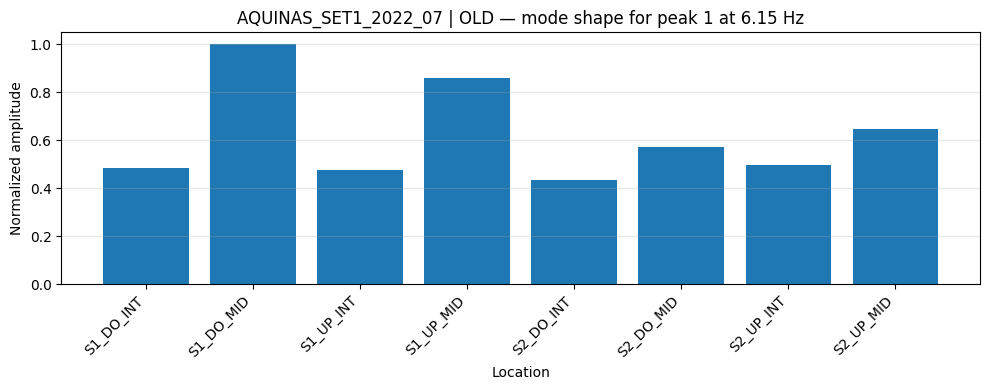

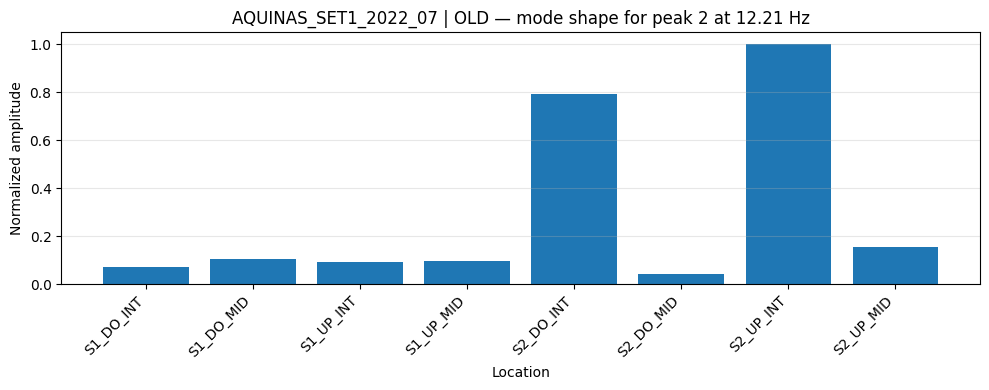

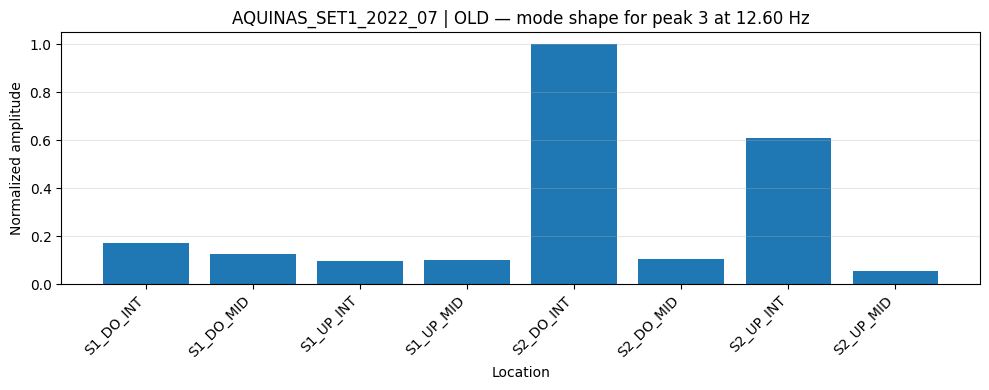

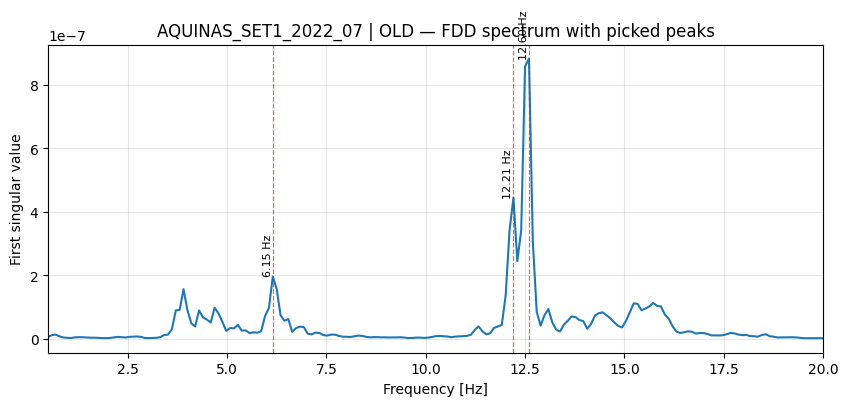

### AQUINAS_SET1_2022_07 | NEW

Frequency [Hz],Singular value
6.15,1.3452e-07
12.60,1.2806e-07
15.82,7.3099e-08


,Peak 1 (6.15 Hz),Peak 2 (12.60 Hz),Peak 3 (15.82 Hz)
Location,,,
S1_DO_INT,0.586,0.029,0.989
S1_DO_MID,0.974,0.199,0.124
S1_UP_INT,0.486,0.098,1.000
S1_UP_MID,1.000,0.129,0.156
S2_DO_INT,0.359,1.000,0.102
S2_DO_MID,0.575,0.222,0.130
S2_UP_INT,0.495,0.815,0.161
S2_UP_MID,0.575,0.053,0.119


,Peak 1 (6.15 Hz),Peak 2 (12.60 Hz),Peak 3 (15.82 Hz)
Location,,,
S1_DO_INT,-180.0,-180.0,180.0
S1_DO_MID,172.8,93.1,166.6
S1_UP_INT,-179.9,-37.0,172.6
S1_UP_MID,173.4,-139.4,-175.6
S2_DO_INT,-164.6,-160.3,-171.6
S2_DO_MID,-168.6,15.6,-145.1
S2_UP_INT,-175.5,167.2,-128.4
S2_UP_MID,-177.5,27.2,-120.3


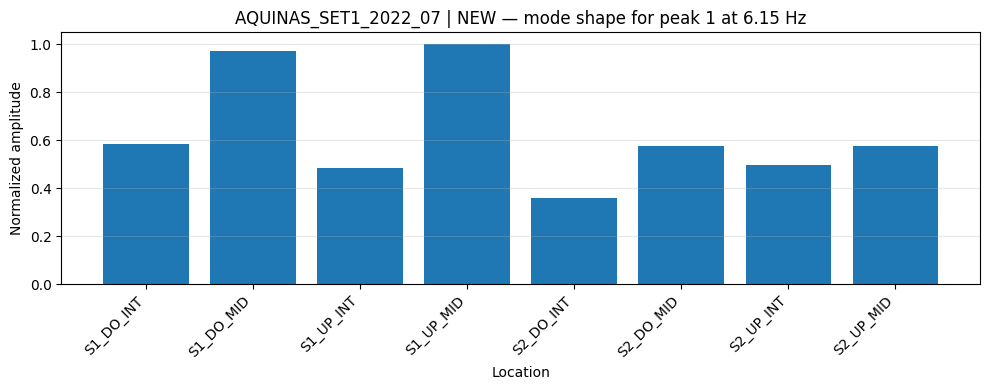

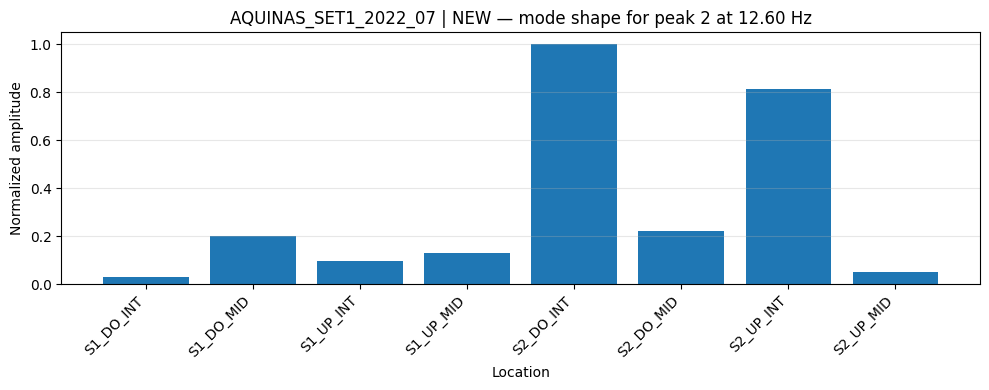

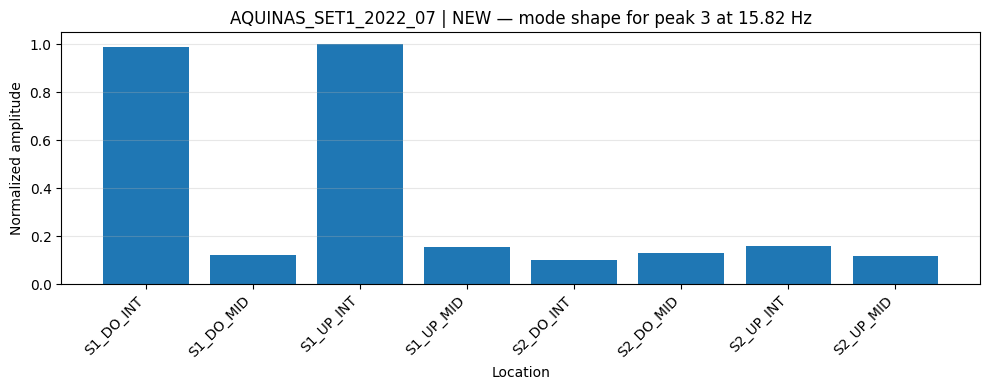

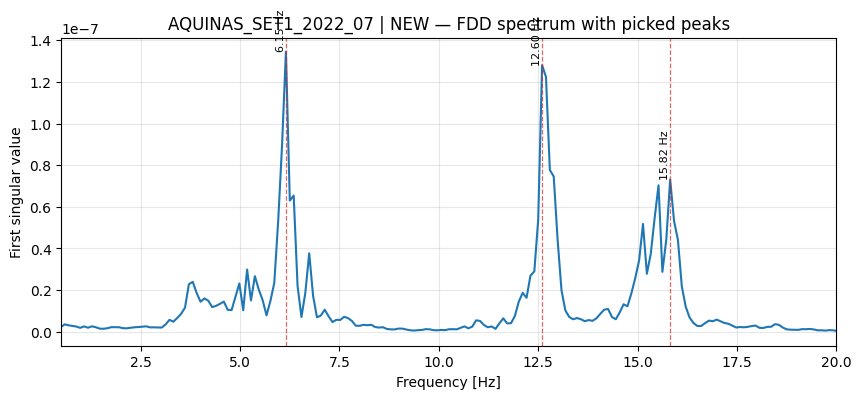

### AQUINAS_SET2_2023_04 | OLD

Frequency [Hz],Singular value
12.60,4.3095e-07
14.84,4.3097e-07
15.53,3.4739e-07


,Peak 1 (12.60 Hz),Peak 2 (14.84 Hz),Peak 3 (15.53 Hz)
Location,,,
S1_DO_INT,0.632,0.756,0.548
S1_DO_MID,0.369,0.055,0.049
S1_UP_INT,0.166,1.000,1.000
S1_UP_MID,0.136,0.331,0.273
S2_DO_INT,1.000,0.047,0.046
S2_DO_MID,0.421,0.118,0.056
S2_UP_INT,0.281,0.149,0.087
S2_UP_MID,0.063,0.081,0.054


,Peak 1 (12.60 Hz),Peak 2 (14.84 Hz),Peak 3 (15.53 Hz)
Location,,,
S1_DO_INT,-180.0,180.0,180.0
S1_DO_MID,56.6,155.4,93.5
S1_UP_INT,-157.3,-159.5,-108.2
S1_UP_MID,-131.8,-165.6,-102.8
S2_DO_INT,104.9,65.9,-36.5
S2_DO_MID,88.1,-166.9,-169.3
S2_UP_INT,-127.4,-89.5,-37.1
S2_UP_MID,-168.2,-125.6,-73.0


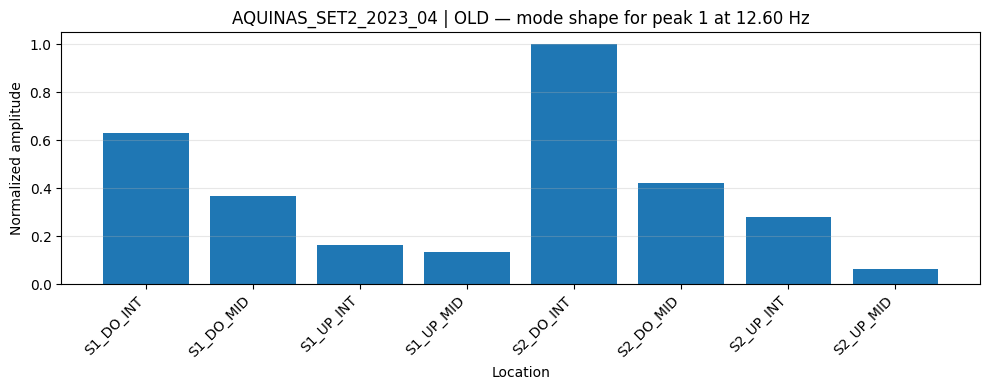

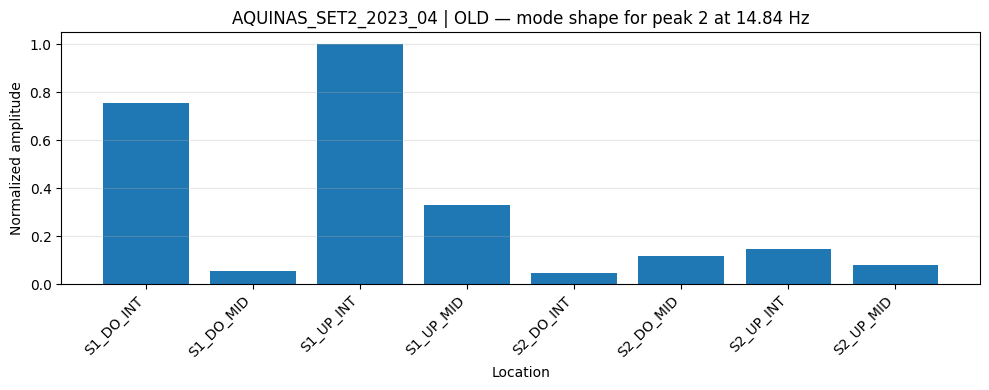

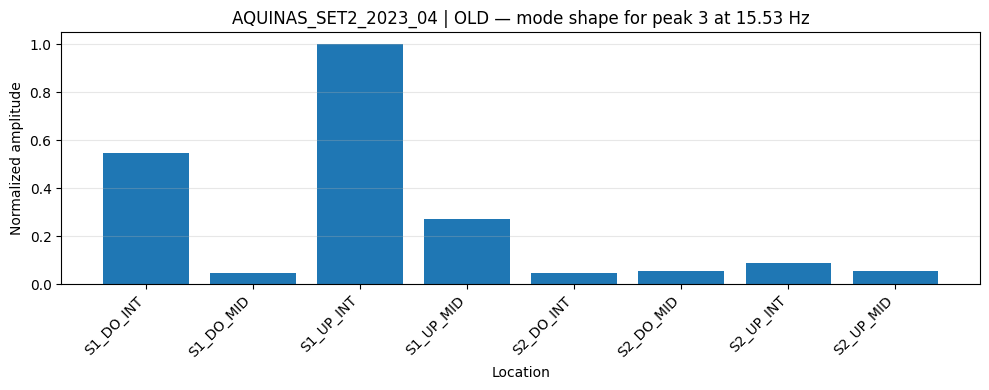

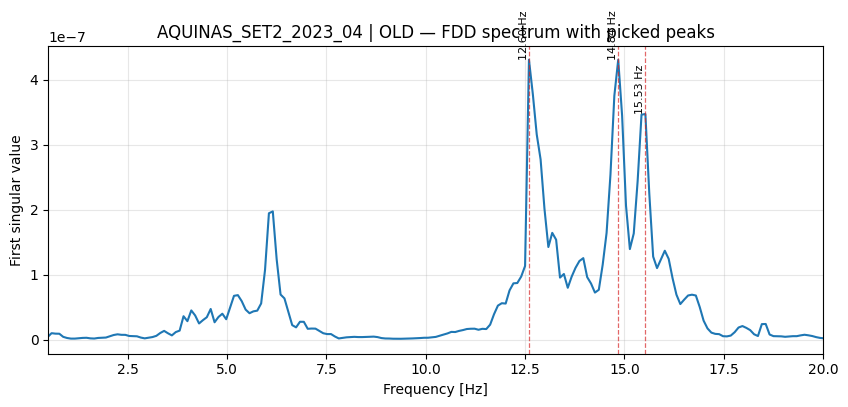

### AQUINAS_SET2_2023_04 | NEW

Frequency [Hz],Singular value
6.25,2.1711e-07
12.60,7.5597e-08
15.53,1.2649e-07


,Peak 1 (6.25 Hz),Peak 2 (12.60 Hz),Peak 3 (15.53 Hz)
Location,,,
S1_DO_INT,0.494,0.423,1.000
S1_DO_MID,0.972,0.494,0.172
S1_UP_INT,0.528,0.022,0.886
S1_UP_MID,1.000,0.080,0.199
S2_DO_INT,0.470,1.000,0.052
S2_DO_MID,0.615,0.398,0.104
S2_UP_INT,0.475,0.164,0.138
S2_UP_MID,0.623,0.136,0.086


,Peak 1 (6.25 Hz),Peak 2 (12.60 Hz),Peak 3 (15.53 Hz)
Location,,,
S1_DO_INT,-180.0,-180.0,180.0
S1_DO_MID,176.7,103.8,166.1
S1_UP_INT,165.2,152.5,-107.6
S1_UP_MID,163.2,99.3,-94.4
S2_DO_INT,148.6,-57.1,168.7
S2_DO_MID,146.7,152.5,172.4
S2_UP_INT,167.9,172.2,-47.1
S2_UP_MID,168.8,157.3,-23.8


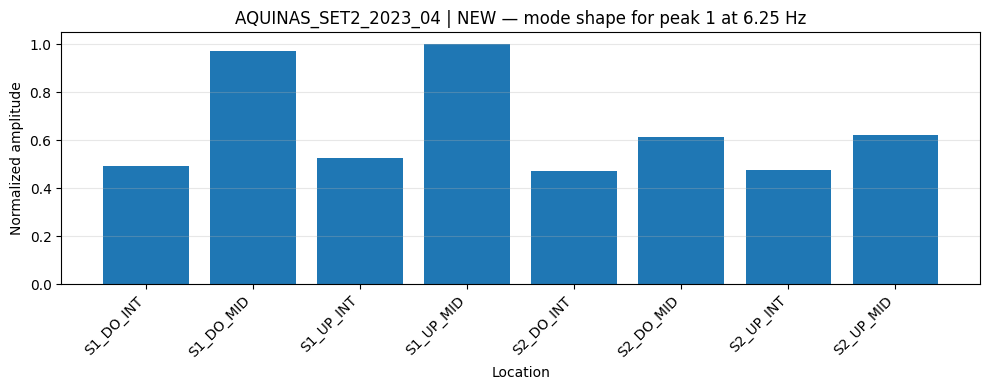

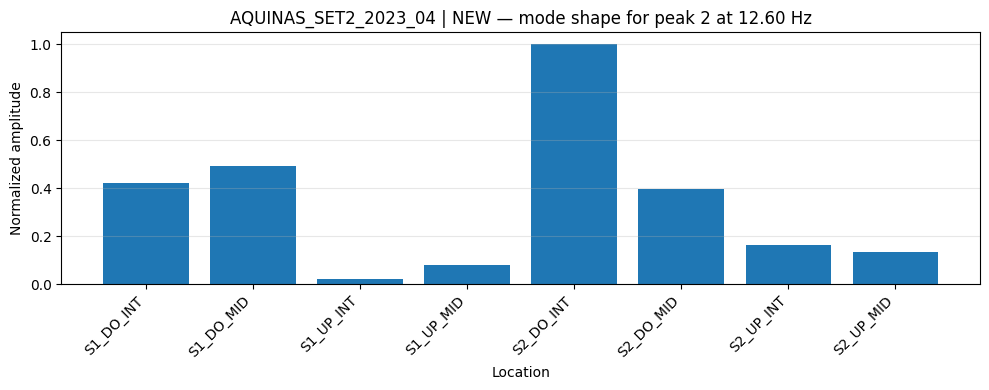

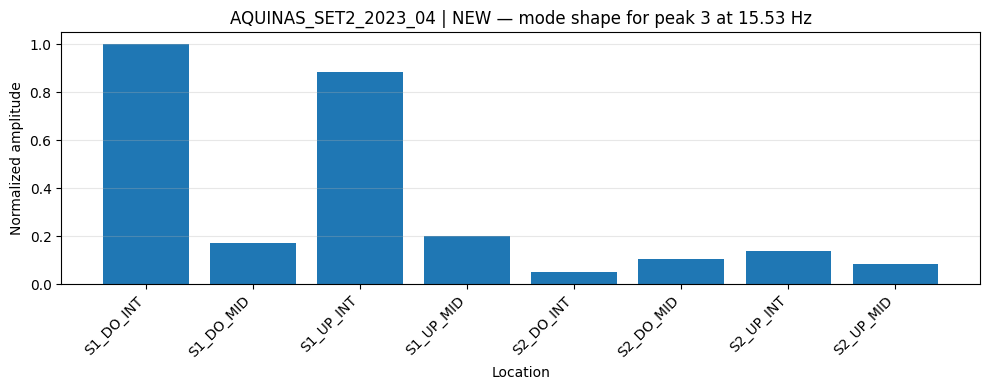

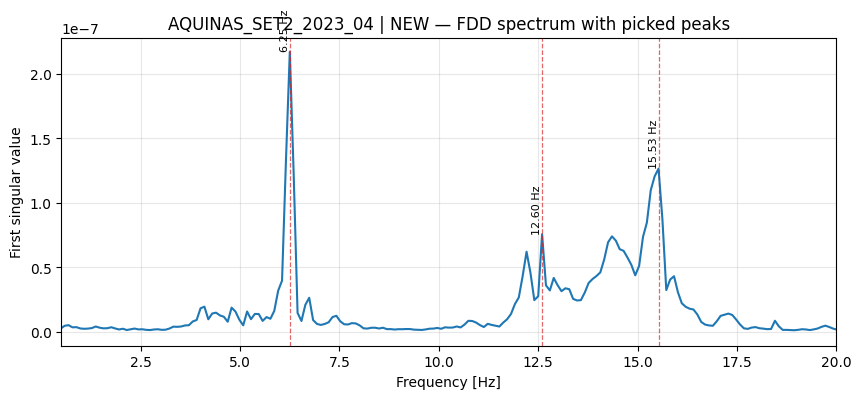

### AQUINAS_SET3_2023_08 | OLD

Frequency [Hz],Singular value
6.05,5.0945e-07
12.70,2.6464e-07
15.04,4.9280e-07


,Peak 1 (6.05 Hz),Peak 2 (12.70 Hz),Peak 3 (15.04 Hz)
Location,,,
S1_DO_INT,0.519,0.812,0.829
S1_DO_MID,0.865,0.280,0.150
S1_UP_INT,0.496,0.074,1.000
S1_UP_MID,1.000,0.132,0.324
S2_DO_INT,0.453,1.000,0.106
S2_DO_MID,0.608,0.401,0.116
S2_UP_INT,0.499,0.668,0.049
S2_UP_MID,0.703,0.144,0.093


,Peak 1 (6.05 Hz),Peak 2 (12.70 Hz),Peak 3 (15.04 Hz)
Location,,,
S1_DO_INT,-180.0,180.0,-180.0
S1_DO_MID,-172.6,-134.3,72.1
S1_UP_INT,148.6,24.0,40.1
S1_UP_MID,145.6,-9.0,35.3
S2_DO_INT,-158.4,-88.2,122.4
S2_DO_MID,179.5,116.9,-148.1
S2_UP_INT,158.8,-105.0,84.1
S2_UP_MID,155.3,-111.0,66.9


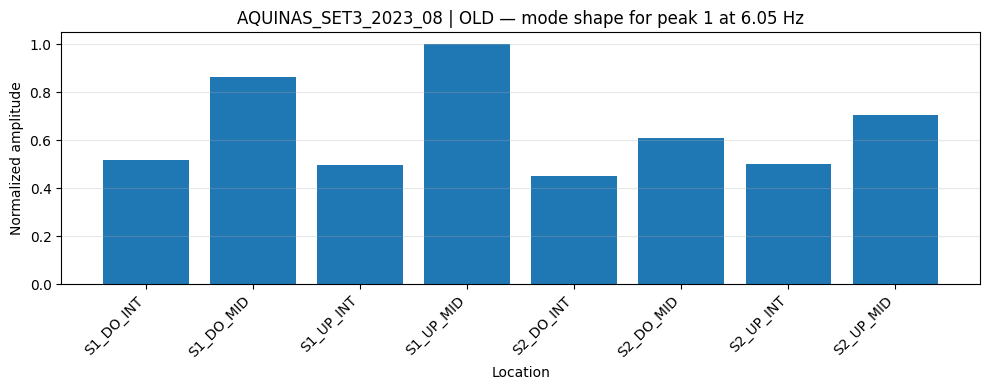

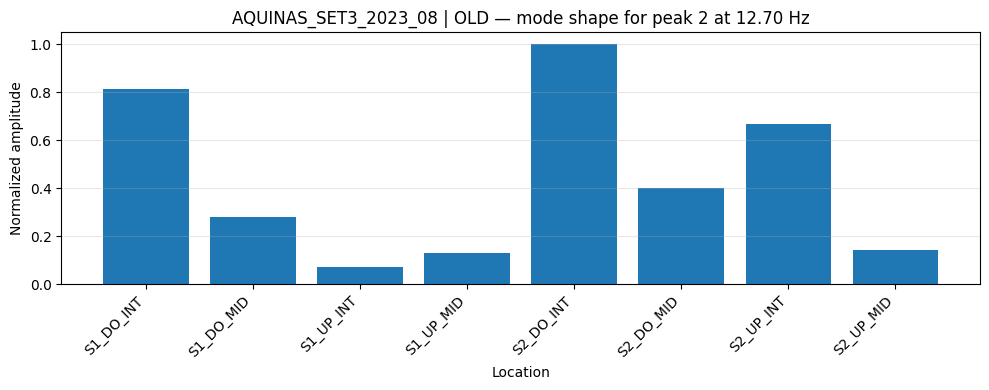

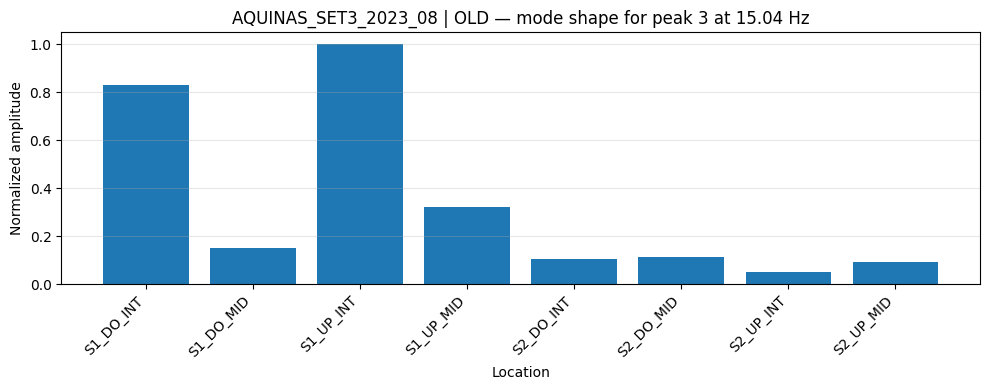

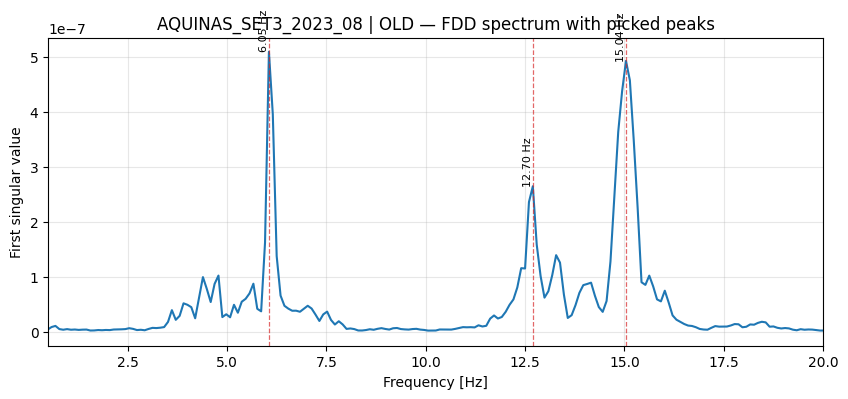

### AQUINAS_SET3_2023_08 | NEW

Frequency [Hz],Singular value
6.15,1.5064e-07
12.21,6.3241e-08
12.60,1.5298e-07


,Peak 1 (6.15 Hz),Peak 2 (12.21 Hz),Peak 3 (12.60 Hz)
Location,,,
S1_DO_INT,0.539,0.131,0.202
S1_DO_MID,0.961,0.159,0.221
S1_UP_INT,0.582,0.086,0.036
S1_UP_MID,1.000,0.163,0.013
S2_DO_INT,0.497,0.936,1.000
S2_DO_MID,0.679,0.157,0.435
S2_UP_INT,0.448,1.000,0.207
S2_UP_MID,0.702,0.140,0.061


,Peak 1 (6.15 Hz),Peak 2 (12.21 Hz),Peak 3 (12.60 Hz)
Location,,,
S1_DO_INT,-180.0,-180.0,-180.0
S1_DO_MID,176.1,101.3,77.7
S1_UP_INT,167.4,174.6,-164.9
S1_UP_MID,167.9,86.4,58.6
S2_DO_INT,166.3,14.4,-14.1
S2_DO_MID,158.8,-171.2,-168.7
S2_UP_INT,171.3,67.6,124.6
S2_UP_MID,168.3,161.3,122.9


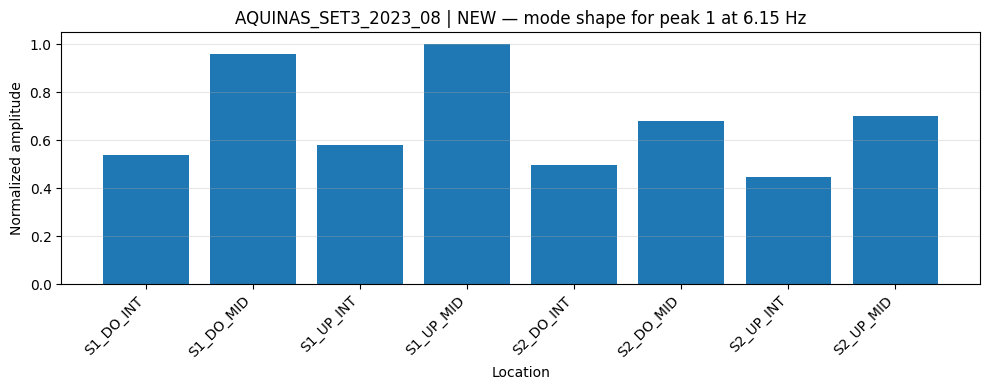

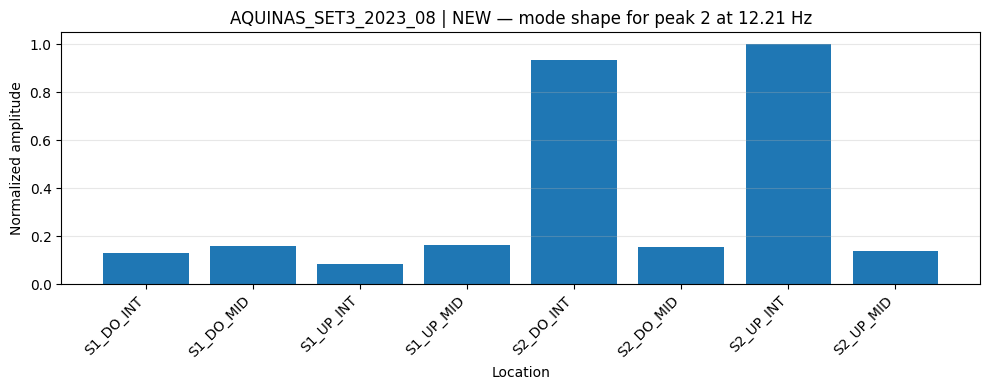

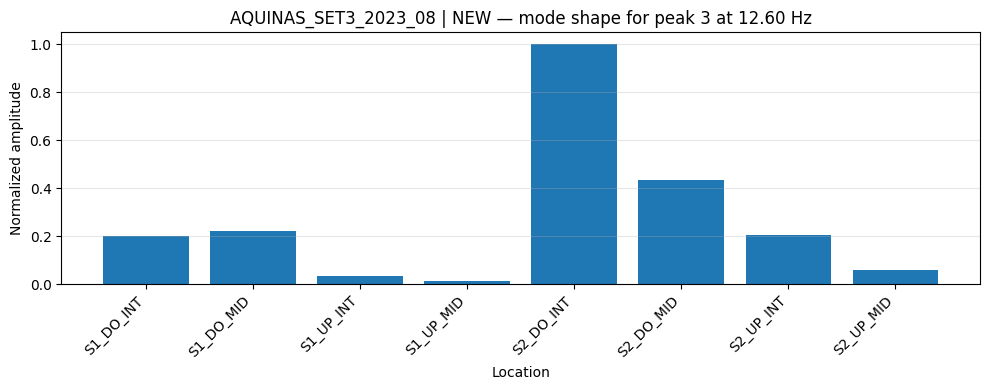

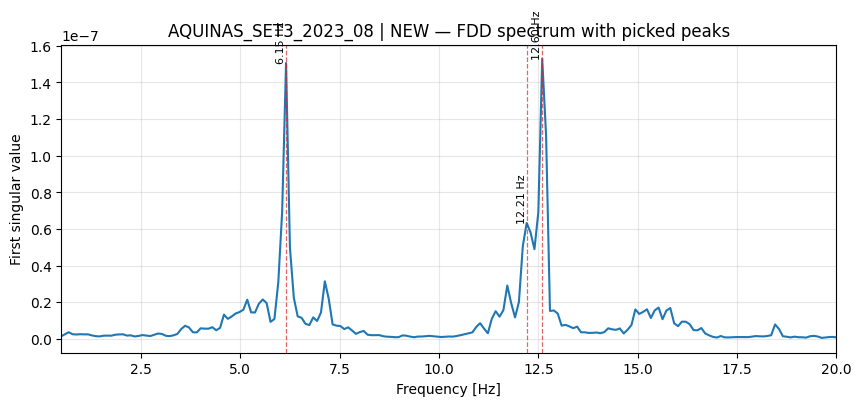

### AQUINAS_SET4_2024_01 | OLD

Frequency [Hz],Singular value
6.15,3.9046e-07
15.23,4.3450e-07
15.82,1.2051e-06


,Peak 1 (6.15 Hz),Peak 2 (15.23 Hz),Peak 3 (15.82 Hz)
Location,,,
S1_DO_INT,0.511,0.728,0.963
S1_DO_MID,1.000,0.242,0.197
S1_UP_INT,0.463,1.000,1.000
S1_UP_MID,0.891,0.485,0.174
S2_DO_INT,0.471,0.137,0.134
S2_DO_MID,0.598,0.142,0.089
S2_UP_INT,0.448,0.067,0.141
S2_UP_MID,0.608,0.031,0.089


,Peak 1 (6.15 Hz),Peak 2 (15.23 Hz),Peak 3 (15.82 Hz)
Location,,,
S1_DO_INT,-180.0,-180.0,-180.0
S1_DO_MID,165.2,41.0,63.6
S1_UP_INT,176.1,45.0,38.0
S1_UP_MID,177.6,34.8,36.9
S2_DO_INT,174.6,123.7,73.9
S2_DO_MID,174.2,-177.7,-176.2
S2_UP_INT,-161.6,130.4,59.0
S2_UP_MID,-169.3,136.0,58.5


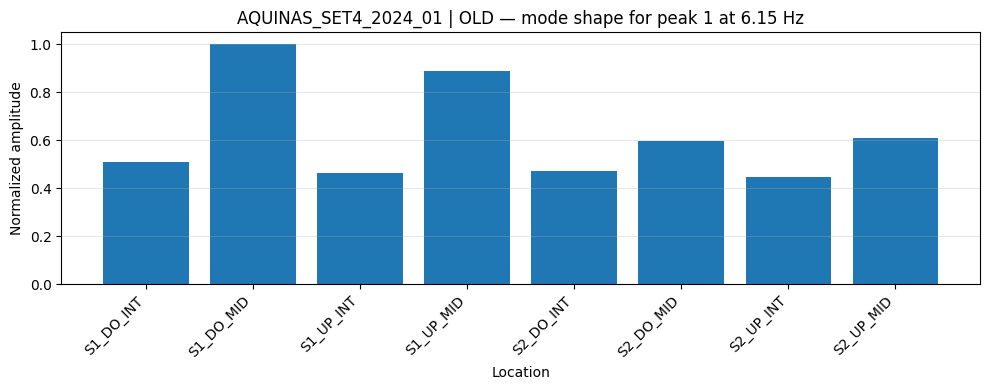

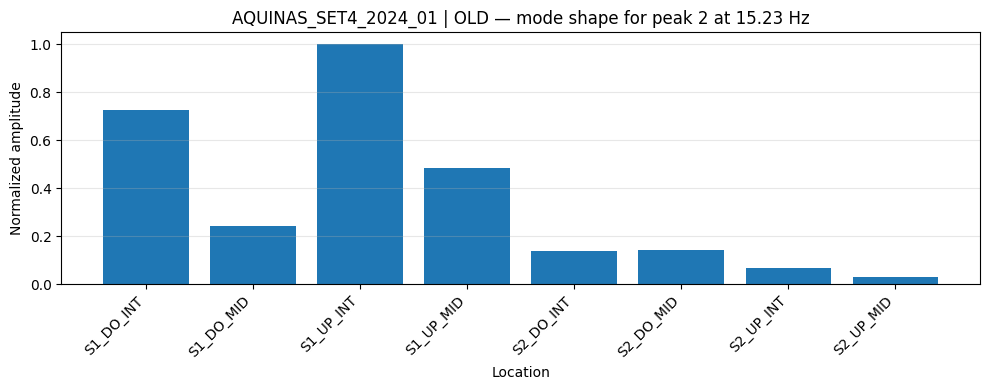

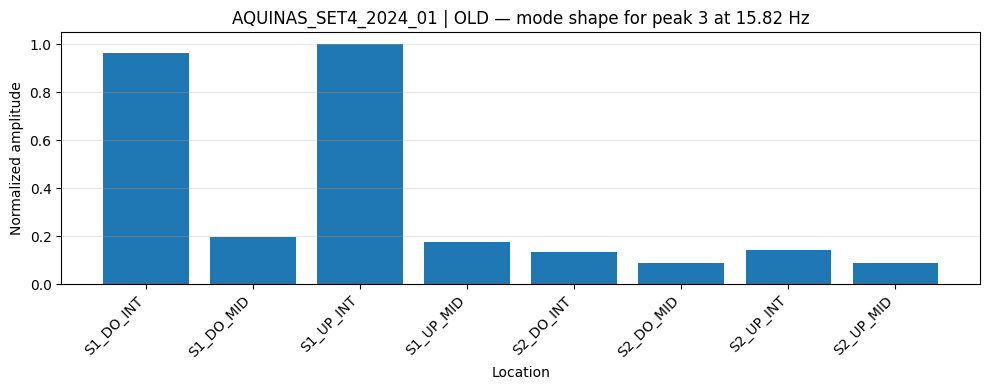

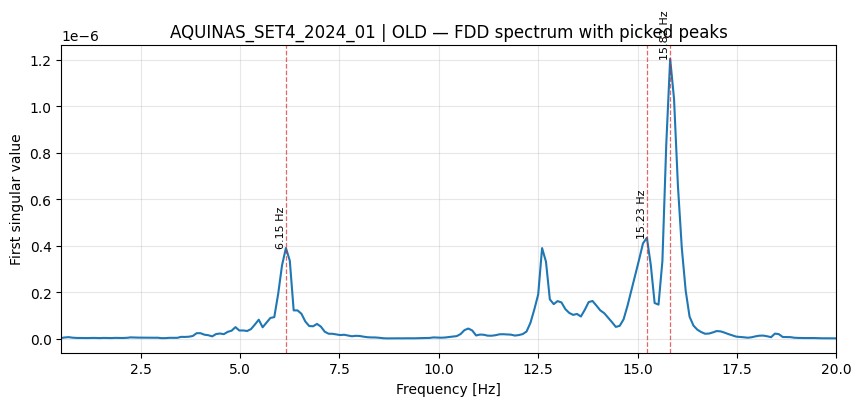

### AQUINAS_SET4_2024_01 | NEW

Frequency [Hz],Singular value
6.25,2.3299e-07
12.60,1.3100e-07
15.33,5.4833e-08


,Peak 1 (6.25 Hz),Peak 2 (12.60 Hz),Peak 3 (15.33 Hz)
Location,,,
S1_DO_INT,0.642,0.122,0.970
S1_DO_MID,0.976,0.206,0.128
S1_UP_INT,0.593,0.016,1.000
S1_UP_MID,1.000,0.047,0.145
S2_DO_INT,0.530,1.000,0.075
S2_DO_MID,0.729,0.318,0.087
S2_UP_INT,0.507,0.056,0.200
S2_UP_MID,0.715,0.117,0.089


,Peak 1 (6.25 Hz),Peak 2 (12.60 Hz),Peak 3 (15.33 Hz)
Location,,,
S1_DO_INT,-180.0,-180.0,180.0
S1_DO_MID,175.1,84.7,154.1
S1_UP_INT,-170.3,-88.3,-158.9
S1_UP_MID,-172.3,100.1,-171.4
S2_DO_INT,160.5,112.4,-125.6
S2_DO_MID,156.9,-36.3,104.3
S2_UP_INT,-175.5,116.9,-66.8
S2_UP_MID,-179.0,-91.7,-92.6


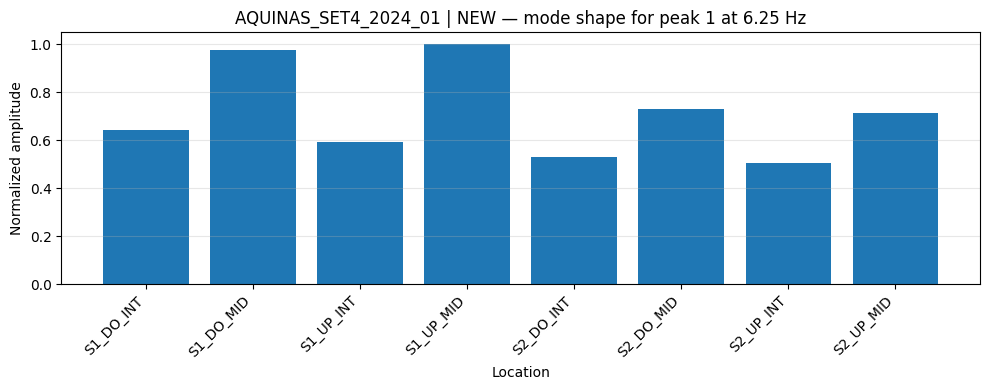

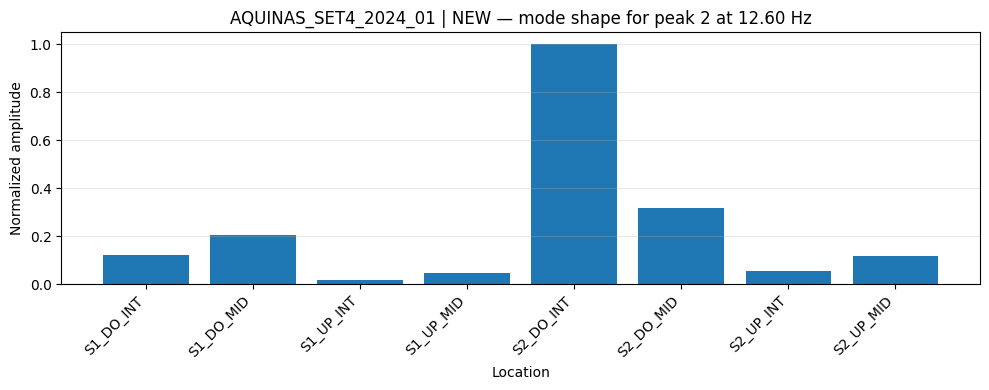

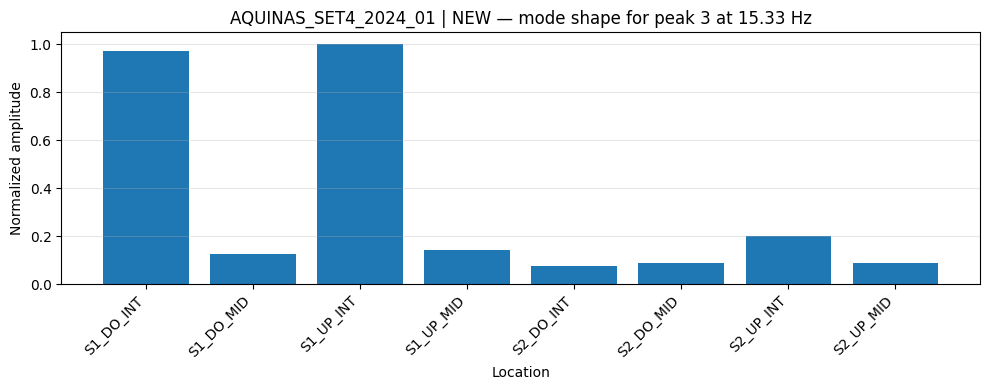

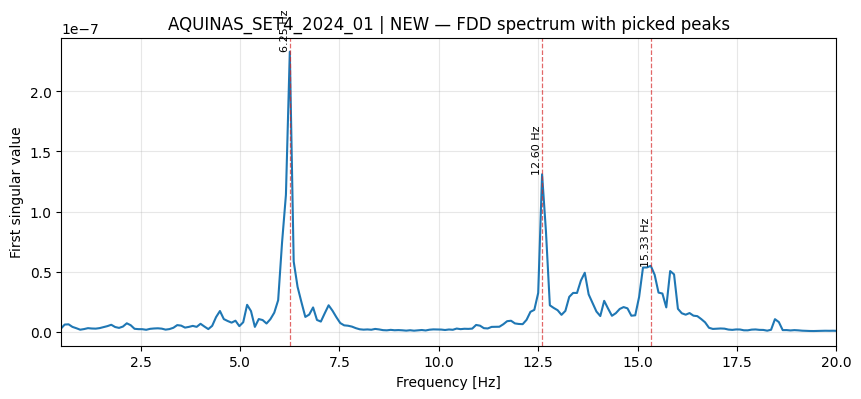

### AQUINAS_SET5_2024_06 | OLD

Frequency [Hz],Singular value
12.60,6.3173e-07
14.45,2.3595e-07
15.72,7.4110e-07


,Peak 1 (12.60 Hz),Peak 2 (14.45 Hz),Peak 3 (15.72 Hz)
Location,,,
S1_DO_INT,0.545,0.876,0.916
S1_DO_MID,0.226,0.265,0.146
S1_UP_INT,0.037,1.000,1.000
S1_UP_MID,0.020,0.332,0.282
S2_DO_INT,1.000,0.355,0.085
S2_DO_MID,0.319,0.155,0.100
S2_UP_INT,0.468,0.322,0.060
S2_UP_MID,0.068,0.145,0.087


,Peak 1 (12.60 Hz),Peak 2 (14.45 Hz),Peak 3 (15.72 Hz)
Location,,,
S1_DO_INT,-180.0,180.0,-180.0
S1_DO_MID,154.6,-161.5,83.9
S1_UP_INT,42.5,-138.5,179.1
S1_UP_MID,-96.7,-126.1,179.7
S2_DO_INT,-178.7,-139.3,129.1
S2_DO_MID,92.2,-172.4,-168.1
S2_UP_INT,-92.2,-84.6,-125.7
S2_UP_MID,-63.1,-124.0,-130.3


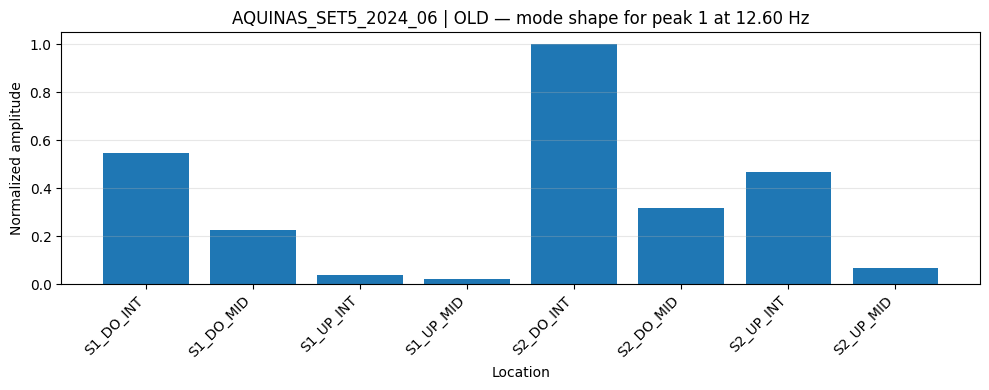

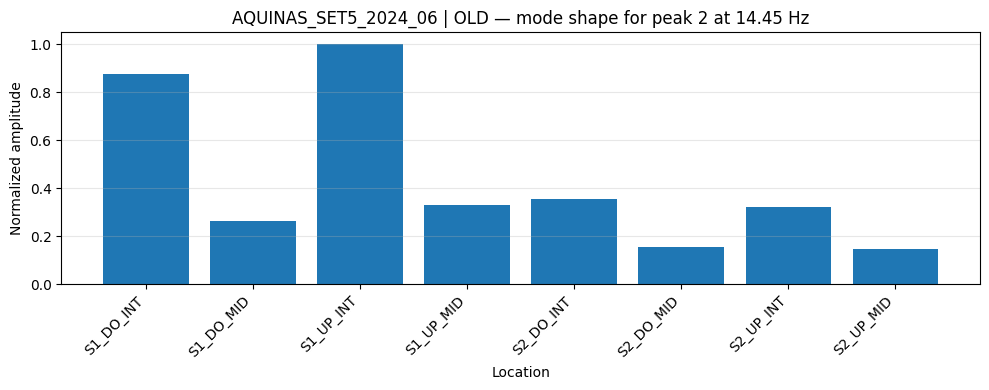

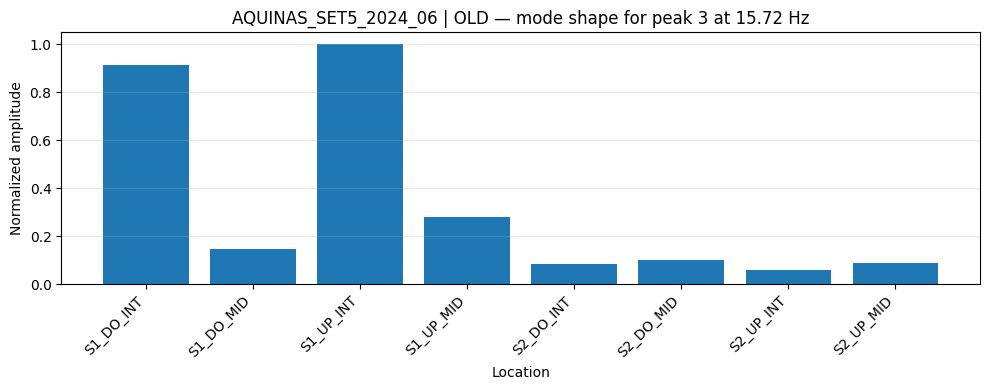

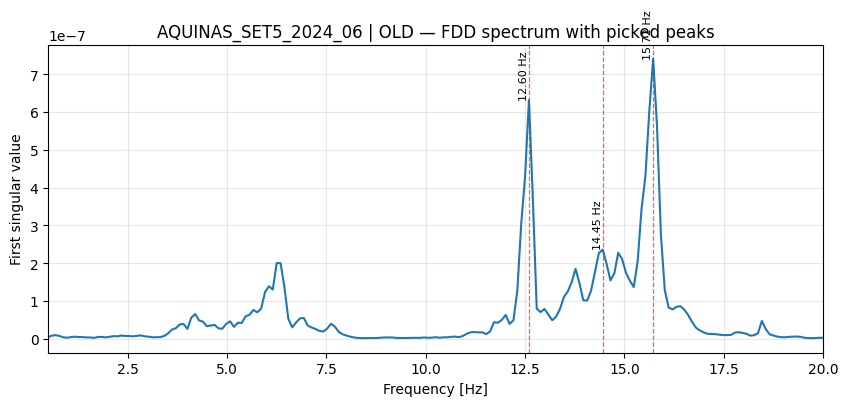

### AQUINAS_SET5_2024_06 | NEW

Frequency [Hz],Singular value
12.60,1.8489e-07
14.55,7.7296e-08
15.04,1.3009e-07


,Peak 1 (12.60 Hz),Peak 2 (14.55 Hz),Peak 3 (15.04 Hz)
Location,,,
S1_DO_INT,0.086,1.000,1.000
S1_DO_MID,0.162,0.286,0.213
S1_UP_INT,0.012,0.930,0.941
S1_UP_MID,0.072,0.254,0.186
S2_DO_INT,1.000,0.122,0.057
S2_DO_MID,0.394,0.072,0.090
S2_UP_INT,0.052,0.269,0.038
S2_UP_MID,0.035,0.032,0.045


,Peak 1 (12.60 Hz),Peak 2 (14.55 Hz),Peak 3 (15.04 Hz)
Location,,,
S1_DO_INT,-180.0,-180.0,180.0
S1_DO_MID,69.0,-175.7,145.5
S1_UP_INT,-69.0,46.5,-76.6
S1_UP_MID,52.3,19.5,-98.8
S2_DO_INT,-169.3,161.9,-128.3
S2_DO_MID,39.7,-27.0,-173.9
S2_UP_INT,13.2,164.7,7.6
S2_UP_MID,-171.3,91.2,-88.4


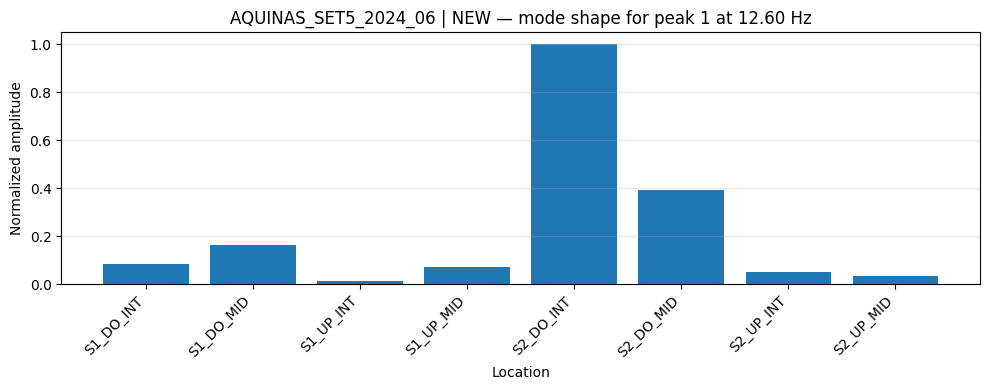

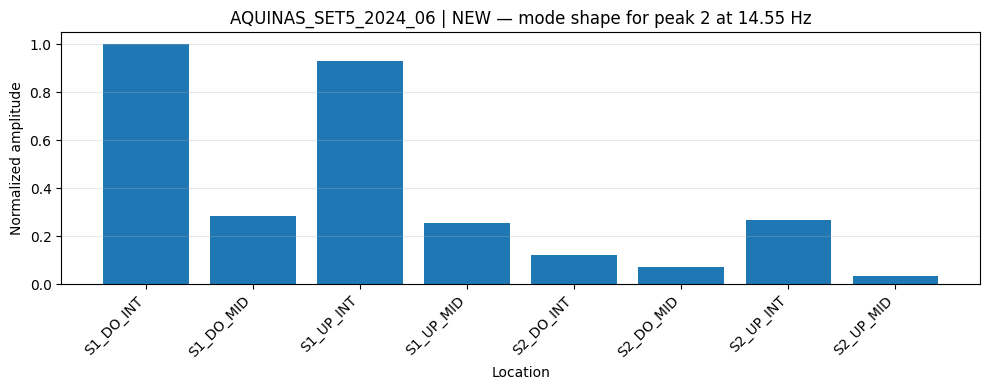

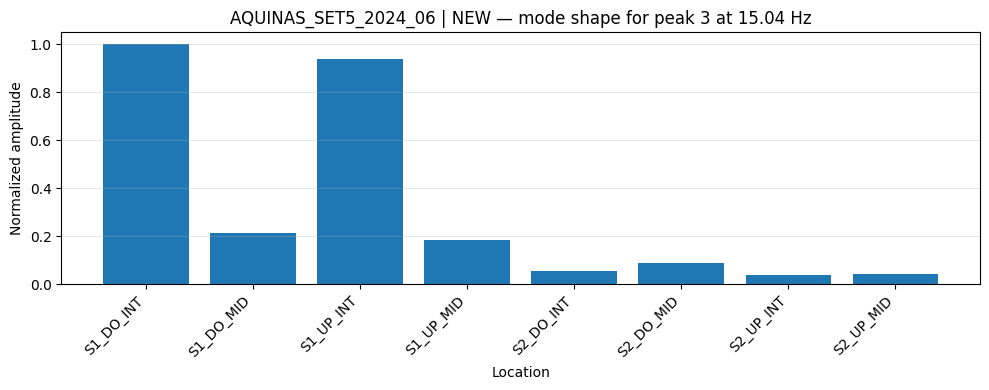

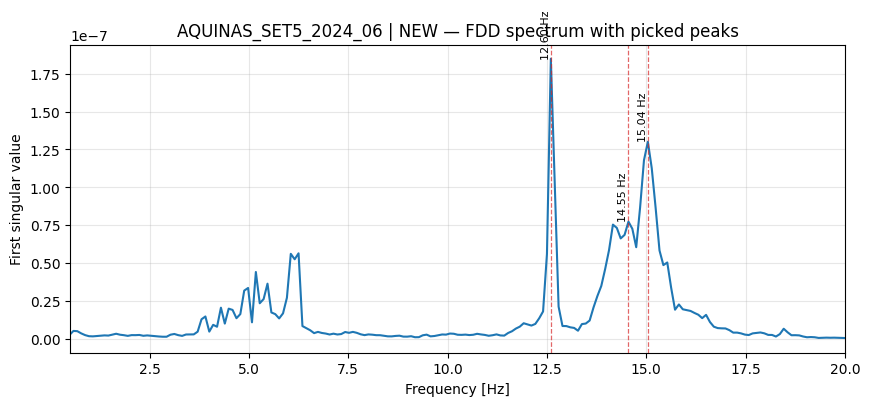

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from aquinas_toolkit.feature_extraction import (
    annotate_mode_shape_locations,
    frequency_domain_decomposition,
    summarize_fdd_mode_shapes,
 )
from aquinas_toolkit.preprocessing import (
    bandpass_filter_waveform_matrix,
    find_common_sensor_events,
    load_common_event_waveform_matrix,
 )

SAMPLE_RATE_HZ = 100.0
LOW_HZ = 0.5
HIGH_HZ = 20.0
MAX_EVENTS_PER_SET = 5
TOP_MODE_COUNT = 3
DECKS = ["OLD", "NEW"]

fdd_overview = []
fdd_results_by_set = {}

for set_dir in sorted(DATASET_ROOT.glob("AQUINAS_SET*")):
    reader = AquinasReader(set_dir)

    for deck in DECKS:
        common_events = find_common_sensor_events(
            reader,
            min_duration_seconds=MIN_DURATION_SECONDS,
            quantity="ACC",
            axis="Z",
            deck=deck,
        )
        if common_events.empty:
            continue

        selected_events = common_events if MAX_EVENTS_PER_SET is None else common_events.head(MAX_EVENTS_PER_SET)
        filtered_events = []
        channel_names = None

        for event in selected_events.itertuples(index=False):
            waveform_matrix = load_common_event_waveform_matrix(
                reader,
                start_time=event.Start_Time,
                end_time=event.End_Time,
                sensor_names=event.sensor_names,
            )
            if channel_names is None:
                channel_names = [column for column in waveform_matrix.columns if column != "timestamp"]
            filtered_matrix = bandpass_filter_waveform_matrix(
                waveform_matrix,
                sampling_rate_hz=SAMPLE_RATE_HZ,
                low_hz=LOW_HZ,
                high_hz=HIGH_HZ,
            )
            filtered_events.append(filtered_matrix)

        fdd_result = frequency_domain_decomposition(
            filtered_events,
            sampling_rate_hz=SAMPLE_RATE_HZ,
            nperseg=1024,
            noverlap=512,
        )
        peak_table, mode_shape_table = summarize_fdd_mode_shapes(
            fdd_result["frequencies_hz"],
            fdd_result["singular_values"],
            fdd_result["mode_shapes"],
            channel_names=channel_names,
            frequency_band_hz=(LOW_HZ, HIGH_HZ),
            n_peaks=TOP_MODE_COUNT,
        )
        mode_shape_locations = annotate_mode_shape_locations(mode_shape_table)

        amplitude_table = (
            mode_shape_locations.pivot(index="position_label", columns="peak_rank", values="mode_shape_amplitude")
            .rename_axis(index="Location", columns="Peak rank")
            .sort_index()
        )
        amplitude_table.columns = [
            f"Peak {peak_rank} ({float(peak_table.iloc[peak_rank - 1]['frequency_hz']):.2f} Hz)"
            for peak_rank in amplitude_table.columns
        ]

        phase_table = (
            mode_shape_locations.pivot(index="position_label", columns="peak_rank", values="mode_shape_phase_deg")
            .rename_axis(index="Location", columns="Peak rank")
            .sort_index()
        )
        phase_table.columns = [
            f"Peak {peak_rank} ({float(peak_table.iloc[peak_rank - 1]['frequency_hz']):.2f} Hz)"
            for peak_rank in phase_table.columns
        ]

        result_key = f"{reader.set_name} | {deck}"
        fdd_overview.append(
            {
                "Dataset": reader.set_name,
                "Deck": deck,
                "ACC_Z channels": int(common_events["channel_count"].iloc[0]),
                "Aligned events available": len(common_events),
                "Aligned events used": len(selected_events),
                "Top FDD peak [Hz]": float(peak_table.iloc[0]["frequency_hz"]),
            }
        )
        fdd_results_by_set[result_key] = {
            "peak_table": peak_table,
            "mode_shape_locations": mode_shape_locations,
            "amplitude_table": amplitude_table,
            "phase_table": phase_table,
            "frequencies_hz": fdd_result["frequencies_hz"],
            "first_singular_value": fdd_result["singular_values"][:, 0],
        }

display(
    pd.DataFrame(fdd_overview)
    .style.hide(axis="index")
    .format({
        "ACC_Z channels": "{:,.0f}",
        "Aligned events available": "{:,.0f}",
        "Aligned events used": "{:,.0f}",
        "Top FDD peak [Hz]": "{:.2f}",
    })
    .set_caption(
        f"Per-deck ACC_Z events after {MIN_DURATION_SECONDS:.0f} s duration filtering, 0.5-20 Hz zero-phase band-pass, and FDD"
    )
)

for result_key, result in fdd_results_by_set.items():
    display(Markdown(f"### {result_key}"))

    display(
        result["peak_table"][["frequency_hz", "singular_value"]]
        .rename(columns={"frequency_hz": "Frequency [Hz]", "singular_value": "Singular value"})
        .style.hide(axis="index")
        .format({"Frequency [Hz]": "{:.2f}", "Singular value": "{:.4e}"})
        .set_caption(f"{result_key} — picked FDD peaks")
    )

    display(
        result["amplitude_table"]
        .style
        .format("{:.3f}")
        .set_caption(f"{result_key} — location-based mode-shape amplitudes")
    )

    display(
        result["phase_table"]
        .style
        .format("{:.1f}")
        .set_caption(f"{result_key} — location-based mode-shape phases [deg]")
    )

    for peak_rank, peak in enumerate(result["peak_table"].itertuples(index=False), start=1):
        peak_rows = result["mode_shape_locations"][result["mode_shape_locations"]["peak_rank"] == peak_rank].copy()
        peak_rows = peak_rows.sort_values(["span", "side", "location"])

        # Compute signed mode shape: amplitude * sign(cos(phase))
        # Positive (blue) = in-phase, Negative (red) = out-of-phase (180° shifted)
        phase_rad = np.deg2rad(peak_rows["mode_shape_phase_deg"].values)
        signed_amplitude = peak_rows["mode_shape_amplitude"].values * np.sign(np.cos(phase_rad))
        bar_colors = ["tab:blue" if val >= 0 else "tab:red" for val in signed_amplitude]

        plt.figure(figsize=(10, 4))
        plt.bar(peak_rows["position_label"], signed_amplitude, color=bar_colors)
        plt.axhline(0, color="black", linewidth=0.8)
        plt.ylim(-1.1, 1.1)
        plt.ylabel("Signed mode shape")
        plt.xlabel("Location")
        plt.title(f"{result_key} — mode shape for peak {peak_rank} at {peak.frequency_hz:.2f} Hz")
        plt.xticks(rotation=45, ha="right")
        plt.grid(axis="y", alpha=0.3)
        plt.tight_layout()
        plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(result["frequencies_hz"], result["first_singular_value"], linewidth=1.5)
    for peak in result["peak_table"].itertuples(index=False):
        plt.axvline(peak.frequency_hz, color="tab:red", linestyle="--", linewidth=0.9, alpha=0.7)
        plt.text(
            peak.frequency_hz,
            peak.singular_value,
            f"{peak.frequency_hz:.2f} Hz",
            rotation=90,
            va="bottom",
            ha="right",
            fontsize=8,
        )
    plt.xlim(LOW_HZ, HIGH_HZ)
    plt.xlabel("Frequency [Hz]")
    plt.ylabel("First singular value")
    plt.title(f"{result_key} — FDD spectrum with picked peaks")
    plt.grid(alpha=0.3)
    plt.show()